In [6]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [73]:
X = np.array([
    [1,4, 1.5, 3.8],
    [3,6, 1.0, 3.1],
    [4,7, 0.8, 3.9],
    [5,8, 0.4, 3.4],
    [7,9, 0.2, 2.8]
])

y=np.array([45.9,76.55,92.35,107.9,128])

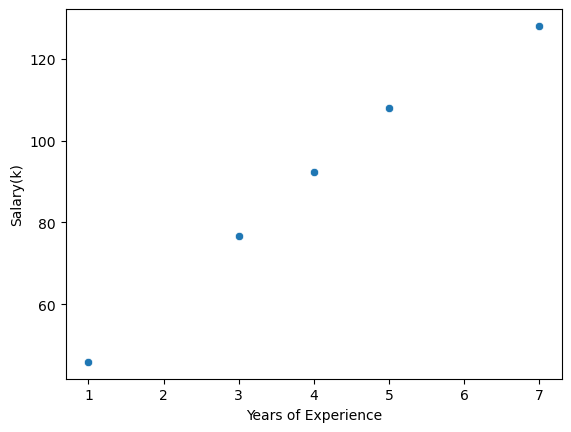

In [74]:
sns.scatterplot(x=X[:,0:1].ravel(),y=y) 
plt.xlabel("Years of Experience") 
plt.ylabel("Salary(k)") 
plt.show()



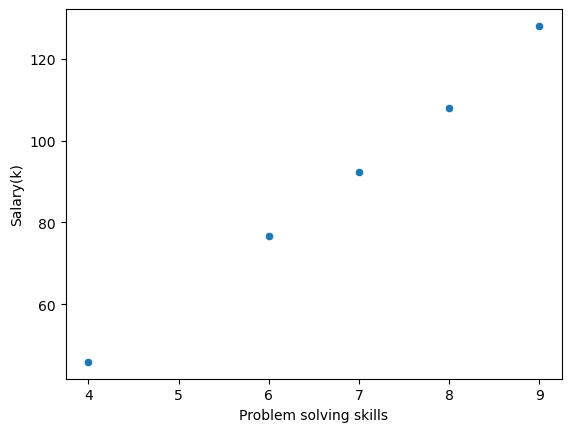

In [75]:
sns.scatterplot(x=X[:,1:2].ravel(),y=y) 
plt.xlabel("Problem solving skills") 
plt.ylabel("Salary(k)") 
plt.show()

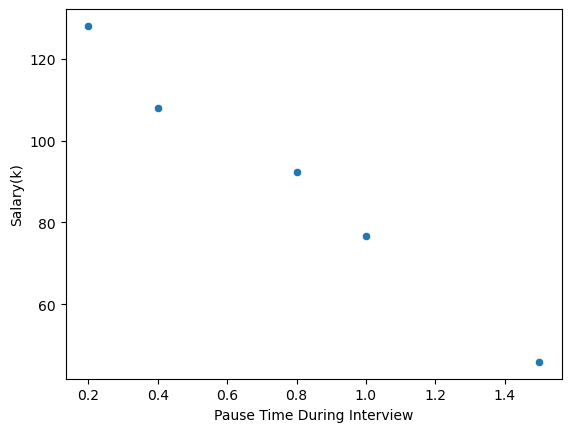

In [76]:
sns.scatterplot(x=X[:,2:3].ravel(),y=y) 
plt.xlabel("Pause Time During Interview") 
plt.ylabel("Salary(k)") 
plt.show()

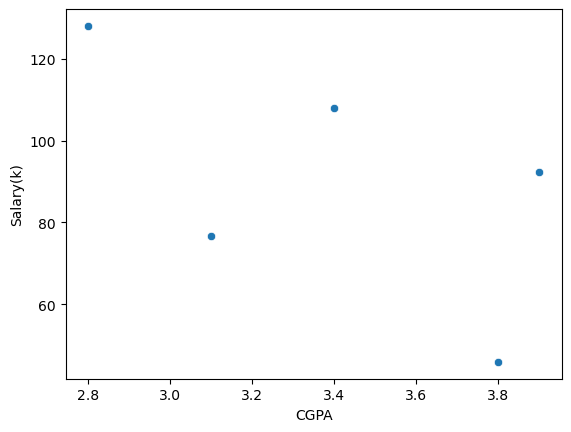

In [77]:
sns.scatterplot(x=X[:,3:].ravel(),y=y) 
plt.xlabel("CGPA") 
plt.ylabel("Salary(k)") 
plt.show()

In [78]:
def make_prediction(X,w,b):

    m=X.shape[0] 
    pred_list = np.zeros((m,)) 
    # X[i] is feature vector rWindowsError
    for i in range(m):
        pred_list[i] = np.dot(w,X[i]) + b

    return pred_list
    
    

In [80]:
m = X.shape[0] 
n = X.shape[1] 

w_init = np.ones((n,)) 
b_init=1.0 

make_prediction(X,w= w_init,b=b_init)

array([11.3, 14.1, 16.7, 17.8, 20. ])

# Calculating Mean square error

In [81]:
def compute_cost(X,y,W,b): 
    m = X.shape[0] 
    pred_list = make_prediction(X,W,b) 
    error = pred_list - y 
    error_squared = error ** 2
    cost = np.sum(error_squared) 

    cost = cost / (2 * m)

    return cost

In [82]:
w_init = np.ones((n,)) 
b_init=1.0 
compute_cost(X,y,w_init,b_init)

np.float64(3060.2095)

# Calculate Gradient Descent 

In [83]:
def calculate_gradient(X,y,W,b): 
    m = X.shape[0] 
    n = X.shape[1]  

    dj_dw = np.zeros((n,)) 
    dj_db =0.0 

    for i in range(m):
        prediction  = np.dot(W,X[i]) + b 
        error = prediction - y[i] 

        for j in range(n):
            dj_dw[j] = dj_dw[j] + (error * X[i,j])

        dj_db = dj_db + error

    return dj_dw /m , dj_db/m   
    

In [84]:
w_init = np.ones((n,)) 
b_init=1.0 
calculate_gradient(X,y,w_init,b_init)

(array([-346.21 , -547.09 ,  -46.502, -245.77 ]), np.float64(-74.16))

# Optimizing cost function using gradient descent

In [85]:
# X = np.array([
#     [1,4, 1.5, 3.8],
#     [3,6, 1.0, 3.1],
#     [4,7, 0.8, 3.9],
#     [5,8, 0.4, 3.4],
#     [7,9, 0.2, 2.8]
# ])

# y=np.array([45,60,72,85,95])

In [86]:
# make_prediction(X,w=[5,10,-2,0.5],b=2)

array([ 45.9 ,  76.55,  92.35, 107.9 , 128.  ])

In [92]:
def gradient_descent(X,y, w_input,b_input,max_iter,alpha=0.01):
    w=w_input 
    b = b_input 

    cost_memo=[] 
    iteration=[] 

    for i in range(max_iter):
        # calculate the gradient 
        dj_dw,dj_db = calculate_gradient(X,y,w,b) 
        #update parameter 
        w= w - alpha * dj_dw 
        b = b- alpha * dj_db 

        cost = compute_cost(X,y,w,b) 
        cost_memo.append(cost) 
        iteration,append(i) 

        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost:0.4f},dj_dw: {dj_dw} ,dj_db : {dj_db} w: {w}, b: {b:0.4f}")

    

    return w, b, cost_memo, iteration


In [ ]:
W_init = np.zeros((n,))
b_init = 0.0

w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input=W_init, b_input=b_init, max_iter=100000, alpha=0.01)